# Predicting HIV Drug Resistance Using Clinical Data

## Overview
This analysis explores whether clinical, demographic, and treatment-related variables can be used to predict HIV drug resistance in patients experiencing ART failure.

## Objective
To build and evaluate a machine learning model that predicts drug resistance using non-genetic patient data, and to interpret the key factors associated with resistance.

## Key Question
Can clinical variables approximate drug resistance risk in the absence of genotypic data?

## Data Loading

In this section, we load the dataset and inspect its structure to understand the available variables and their formats.

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\wbakka\Desktop\BIOINFORMATICS\Projects\HIV_drug_resistance\data\raw\drug_resistance.csv")
df.head()

,Date,year,sample,SEX,YEAR,Ethnicity,Education,Occupation,Marital status,Transmission category,...,ddI,FTC,3TC,TDF,NNRTI MU,DOR,NNRTIs,ETR,NNRTIs.1,RPV
0,2019/07/29,2019,VF-CQ-1000,2,62,1,1,2,3,3,...,S,S,S,S,K103N,S,H,S,H,S
1,2019/07/29,2019,VF-CQ-1002,1,48,1,2,4,1,5,...,I,H,H,L,"V106M, Y181C, G190A",H,H,I,H,H
2,2019/08/05,2019,VF-CQ-1007,1,32,1,3,4,2,3,...,S,S,S,S,N,S,S,S,S,S
3,2019/08/05,2019,VF-CQ-1008,1,65,3,4,5,4,5,...,S,S,S,S,N,S,S,S,S,S
4,2019/08/05,2019,VF-CQ-1012,1,38,1,2,4,1,4,...,H,I,I,H,"V106M, V179D, Y181C",I,H,I,H,I


## Data Overview

We examine the dataset structure, including:
- Number of rows and columns  
- Variable types  
- Initial preview of the data  

This helps identify potential issues such as missing values or incorrect data types.

In [2]:
df.shape
df.columns
df.dtypes
df.info

<bound method DataFrame.info of             Date  year      sample  SEX YEAR  Ethnicity  Education  \
0     2019/07/29  2019  VF-CQ-1000    2   62          1          1   
1     2019/07/29  2019  VF-CQ-1002    1   48          1          2   
2     2019/08/05  2019  VF-CQ-1007    1   32          1          3   
3     2019/08/05  2019  VF-CQ-1008    1   65          3          4   
4     2019/08/05  2019  VF-CQ-1012    1   38          1          2   
...          ...   ...         ...  ...  ...        ...        ...   
1517  2019/07/22  2019   VF-CQ-981    2   52          1          2   
1518  2019/07/22  2019   VF-CQ-983    1   40          1          3   
1519  2019/07/22  2019   VF-CQ-984    1   68          1          1   
1520  2019/07/22  2019   VF-CQ-986    1   54          1          4   
1521  2019/07/29  2019   VF-CQ-988    1   53          1          2   

      Occupation  Marital status  Transmission category  ... ddI  FTC 3TC TDF  \
0              2               3              

We need to expand the columns so that we can see the drug columns and later see the values in those columns.

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head()

,Date,year,sample,SEX,YEAR,Ethnicity,Education,Occupation,Marital status,Transmission category,Baseline CD4+T-cell count(cells/μL),Baseline HIV VL\n(copies/mL plasma)[M(IQR)],Initial ART regimen,ART duration,HIV-1YX,PI MU,ATV/r,DRV/r,FPV/r,IDV/r,LPV/r,NFV,SQV/r,TPV/r,NRTI MU,ABC,AZT,d4T,ddI,FTC,3TC,TDF,NNRTI MU,DOR,NNRTIs,ETR,NNRTIs.1,RPV
0,2019/07/29,2019,VF-CQ-1000,2,62,1,1,2,3,3,72,6270000.0,2NRTIs+NNRTIs,24,B+C,N,S,S,S,S,S,S,S,S,N,S,S,S,S,S,S,S,K103N,S,H,S,H,S
1,2019/07/29,2019,VF-CQ-1002,1,48,1,2,4,1,5,10,6500.0,2NRTIs+NNRTIs,24,CRF01_AE,N,S,S,S,S,S,S,S,S,"D67N, K70E, M184I",I,S,I,I,H,H,L,"V106M, Y181C, G190A",H,H,I,H,H
2,2019/08/05,2019,VF-CQ-1007,1,32,1,3,4,2,3,68,356000.0,2NRTIs+NNRTIs,84,CRF07_BC,N,S,S,S,S,S,S,S,S,N,S,S,S,S,S,S,S,N,S,S,S,S,S
3,2019/08/05,2019,VF-CQ-1008,1,65,3,4,5,4,5,257,38900.0,2NRTIs+NNRTIs,36,B+C,N,S,S,S,S,S,S,S,S,N,S,S,S,S,S,S,S,N,S,S,S,S,S
4,2019/08/05,2019,VF-CQ-1012,1,38,1,2,4,1,4,12,335000.0,2NRTIs+NNRTIs,13,B+C,N,S,S,S,S,S,S,S,S,"K65R, Y115F",H,S,H,H,I,I,H,"V106M, V179D, Y181C",I,H,I,H,I


In [4]:
df.columns.tolist()

['Date',
 'year',
 'sample',
 'SEX',
 'YEAR',
 'Ethnicity',
 'Education',
 'Occupation',
 'Marital status',
 'Transmission category',
 'Baseline CD4+T-cell count(cells/μL)',
 'Baseline HIV VL\n(copies/mL plasma)[M(IQR)]',
 'Initial ART regimen',
 'ART duration ',
 'HIV-1YX',
 'PI MU',
 'ATV/r',
 'DRV/r',
 'FPV/r',
 'IDV/r',
 'LPV/r',
 'NFV',
 'SQV/r',
 'TPV/r',
 'NRTI MU',
 'ABC',
 'AZT',
 'd4T',
 'ddI',
 'FTC',
 '3TC',
 'TDF',
 'NNRTI MU',
 'DOR',
 'NNRTIs',
 'ETR',
 'NNRTIs.1',
 'RPV']

In [5]:
selected_drugs = ["AZT", "TDF", "3TC"]

for col in selected_drugs:
    print(col, df[col].unique())

AZT <StringArray>
['S', 'L', 'I', 'H', 'P', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限']
Length: 9, dtype: str
TDF <StringArray>
['S', 'L', 'H', 'I', 'P', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限']
Length: 9, dtype: str
3TC <StringArray>
['S', 'H', 'I', 'P', '低于检测下限', '低于检出限', '低于检出下限', 'L', '低于检测限']
Length: 9, dtype: str


## Data Cleaning
The dataset contains inconsistencies such as:
- Non-standard entries such as multilingual labels
- Formatting issues like extra spaces or irregular values.

These are cleaned to ensure consistent and reliable analysis.

In [6]:
drug_columns = [
    'ATV/r', 'DRV/r', 'FPV/r', 'IDV/r', 'LPV/r', 'NFV', 'SQV/r', 'TPV/r',
    'ABC', 'AZT', 'd4T', 'ddI', 'FTC', '3TC', 'TDF',
    'DOR', 'ETR', 'RPV'
]

for col in drug_columns:
    print(f"{col}: {df[col].unique()}")

ATV/r: <StringArray>
['S', 'L', 'P', 'H', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限', 'I']
Length: 9, dtype: str
DRV/r: <StringArray>
['S', 'I', '低于检测下限', 'L', '低于检出限', '低于检出下限', '低于检测限', 'P']
Length: 8, dtype: str
FPV/r: <StringArray>
['S', 'L', 'P', 'H', 'I', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限']
Length: 9, dtype: str
IDV/r: <StringArray>
['S', 'I', 'P', 'H', '低于检测下限', '低于检出限', '低于检出下限', 'L', '低于检测限']
Length: 9, dtype: str
LPV/r: <StringArray>
['S', 'L', 'P', 'H', 'I', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限']
Length: 9, dtype: str
NFV: <StringArray>
['S', 'H', 'I', 'P', 'L', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限']
Length: 9, dtype: str
SQV/r: <StringArray>
['S', 'I', 'P', 'H', 'L', '低于检测下限', '低于检出限', '低于检出下限', '低于检测限', '低于检出限']
Length: 10, dtype: str
TPV/r: <StringArray>
['S', 'L', 'I', '低于检测下限', 'P', '低于检出限', '低于检出下限', 'H', '低于检测限']
Length: 9, dtype: str
ABC: <StringArray>
[                      'S',                       'I',
                       'H',                       'L',
           

These mean; “低于” = below “检测/检出” = detection. Since these are not resistance values they will be treated as unknown/missing. So the next step is to standardize the text and replace the invalid values with NaN.

In [7]:
for col in drug_columns:
    df[col] = df[col].astype(str).str.strip().str.upper()
invalid_values = [
    '低于检测下限',
    '低于检出限',
    '低于检出下限',
    '低于检测限'
]
for col in drug_columns:
    df[col] = df[col].replace(invalid_values, np.nan)

Since there are also some corrupted entries like; 'H 载量低？' we need to clean it so that we remain with only these; S, I, L, P, H, NaN and we shall also verify the cleaning thereafter.

In [8]:
for col in drug_columns:
    df[col] = df[col].str.replace(r'[^SILPH]', '', regex=True)
for col in drug_columns:
    print(col, df[col].unique())

ATV/r <StringArray>
['S', 'L', 'P', 'H', nan, 'I']
Length: 6, dtype: str
DRV/r <StringArray>
['S', 'I', nan, 'L', 'P']
Length: 5, dtype: str
FPV/r <StringArray>
['S', 'L', 'P', 'H', 'I', nan]
Length: 6, dtype: str
IDV/r <StringArray>
['S', 'I', 'P', 'H', nan, 'L']
Length: 6, dtype: str
LPV/r <StringArray>
['S', 'L', 'P', 'H', 'I', nan]
Length: 6, dtype: str
NFV <StringArray>
['S', 'H', 'I', 'P', 'L', nan]
Length: 6, dtype: str
SQV/r <StringArray>
['S', 'I', 'P', 'H', 'L', nan, '']
Length: 7, dtype: str
TPV/r <StringArray>
['S', 'L', 'I', nan, 'P', 'H']
Length: 6, dtype: str
ABC <StringArray>
['S', 'I', 'H', 'L', nan, 'P']
Length: 6, dtype: str
AZT <StringArray>
['S', 'L', 'I', 'H', 'P', nan]
Length: 6, dtype: str
d4T <StringArray>
['S', 'I', 'H', 'L', 'P', nan]
Length: 6, dtype: str
ddI <StringArray>
['S', 'I', 'H', 'P', 'L', nan]
Length: 6, dtype: str
FTC <StringArray>
['S', 'H', 'I', 'P', nan, 'L']
Length: 6, dtype: str
3TC <StringArray>
['S', 'H', 'I', 'P', nan, 'L']
Length: 6, dtyp

## Outcome Definition
Drug resistance is defined at the patient level based on drug susceptibility results:

- Resistant (1): If any drug shows Intermediate (I), Low (L), Potential (P), or High (H) resistance  
- Non-resistant (0): If all drugs are Susceptible (S)

This transforms multiple drug-level observations into a single binary outcome for modeling.

So we shall begin by dropping rows with no drug information.
Then we shall define resistant_values = ['I', 'H', 'L', 'P']
And eventually create target column and validate the outcome by checking the distribution.

In [9]:
df = df.dropna(subset=drug_columns, how='all')
resistant_values = ['I', 'H', 'L', 'P']
df['resistant'] = df[drug_columns].apply(
    lambda row: 1 if any(val in resistant_values for val in row if pd.notna(val)) else 0,
    axis=1
)
df['resistant'].value_counts()
df['resistant'].value_counts(normalize=True)

resistant
1    0.588936
0    0.411064
Name: proportion, dtype: float64

We can see that this dataset is moderately balanced, with a slight majority of resistant cases. This is good because the model can learn both classes and metrics like ROC-AUC will be meaningful. So we still carry out sanity checks to check for the non-resistant(Those with only S) and the resistant(with at least one I/H/L/P).

In [10]:
df[df['resistant'] == 0][drug_columns].head()

,ATV/r,DRV/r,FPV/r,IDV/r,LPV/r,NFV,SQV/r,TPV/r,ABC,AZT,d4T,ddI,FTC,3TC,TDF,DOR,ETR,RPV
0,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S
2,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S
3,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S
5,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S
10,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S


In [11]:
df[df['resistant'] == 1][drug_columns].head()

,ATV/r,DRV/r,FPV/r,IDV/r,LPV/r,NFV,SQV/r,TPV/r,ABC,AZT,d4T,ddI,FTC,3TC,TDF,DOR,ETR,RPV
1,S,S,S,S,S,S,S,S,I,S,I,I,H,H,L,H,I,H
4,S,S,S,S,S,S,S,S,H,S,H,H,I,I,H,I,I,I
6,S,S,S,S,S,S,S,S,H,S,I,H,H,H,I,I,H,H
7,S,S,S,S,S,S,S,S,H,S,H,H,H,H,H,H,P,P
8,S,S,S,S,S,S,S,S,S,S,S,S,S,S,S,P,I,I


## Feature Selection

We select relevant predictors including:
- Demographics (sex, ethnicity, transmission category)
- Clinical variables (CD4 count, viral load)
- Treatment variables (ART regimen, ART duration)

Variables directly related to resistance like mutation or drug result columns are excluded to prevent data leakage.

In [12]:
df.columns.tolist()

['Date',
 'year',
 'sample',
 'SEX',
 'YEAR',
 'Ethnicity',
 'Education',
 'Occupation',
 'Marital status',
 'Transmission category',
 'Baseline CD4+T-cell count(cells/μL)',
 'Baseline HIV VL\n(copies/mL plasma)[M(IQR)]',
 'Initial ART regimen',
 'ART duration ',
 'HIV-1YX',
 'PI MU',
 'ATV/r',
 'DRV/r',
 'FPV/r',
 'IDV/r',
 'LPV/r',
 'NFV',
 'SQV/r',
 'TPV/r',
 'NRTI MU',
 'ABC',
 'AZT',
 'd4T',
 'ddI',
 'FTC',
 '3TC',
 'TDF',
 'NNRTI MU',
 'DOR',
 'NNRTIs',
 'ETR',
 'NNRTIs.1',
 'RPV',
 'resistant']

We need to clean the column names and check again.

In [13]:
df.columns = df.columns.str.strip()  # remove spaces
df.columns = df.columns.str.replace('\n', ' ')  # remove newline
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)  # normalize spaces

In [14]:
df.columns.tolist()

['Date',
 'year',
 'sample',
 'SEX',
 'YEAR',
 'Ethnicity',
 'Education',
 'Occupation',
 'Marital status',
 'Transmission category',
 'Baseline CD4+T-cell count(cells/μL)',
 'Baseline HIV VL (copies/mL plasma)[M(IQR)]',
 'Initial ART regimen',
 'ART duration',
 'HIV-1YX',
 'PI MU',
 'ATV/r',
 'DRV/r',
 'FPV/r',
 'IDV/r',
 'LPV/r',
 'NFV',
 'SQV/r',
 'TPV/r',
 'NRTI MU',
 'ABC',
 'AZT',
 'd4T',
 'ddI',
 'FTC',
 '3TC',
 'TDF',
 'NNRTI MU',
 'DOR',
 'NNRTIs',
 'ETR',
 'NNRTIs.1',
 'RPV',
 'resistant']

## Handling Missing Data

Missing values are handled as follows:

- Numerical variables: Imputed using the median to reduce sensitivity to outliers  
- Categorical variables: Replaced with "Unknown" to preserve missingness as information  

This ensures a complete dataset for modeling.
We shall define our features and create an X(features) and Y(resistant). We shall also check for missing values within the entire dataset and provide view a summary.

In [15]:
features = [
    'SEX',
    'Ethnicity',
    'Transmission category',
    'Baseline CD4+T-cell count(cells/μL)',
    'Baseline HIV VL (copies/mL plasma)[M(IQR)]',
    'Initial ART regimen',
    'ART duration'
]
X = df[features]
y = df['resistant']
X.isnull().sum().sort_values(ascending=False)

Baseline CD4+T-cell count(cells/μL)           166
Baseline HIV VL (copies/mL plasma)[M(IQR)]     43
ART duration                                    5
Initial ART regimen                             4
Transmission category                           0
SEX                                             0
Ethnicity                                       0
dtype: int64

The dataset shows variable levels of missingness across key clinical predictors. The baseline CD4 count shows the highest proportion of missing values (n=166), suggesting potential non-random missingness possibly related to clinical or resource factors. The baseline viral load has moderate missingness (n=43), while ART duration (n=5) and initial ART regimen (n=4) have minimal missing values. Demographic variables including sex, ethnicity, and transmission category are complete. Overall, missingness is concentrated in key laboratory variables, necessitating careful imputation to preserve data integrity and avoid bias in downstream modeling.

We shall use median imputation for numerical predictors. But our data likely contains numbers stored as text and special formatting so we shall convert these columns to numeric first and then apply median imputation.

In [16]:
X.columns.tolist()

['SEX',
 'Ethnicity',
 'Transmission category',
 'Baseline CD4+T-cell count(cells/μL)',
 'Baseline HIV VL (copies/mL plasma)[M(IQR)]',
 'Initial ART regimen',
 'ART duration']

In [17]:
num_cols = [
    'Baseline CD4+T-cell count(cells/μL)',
    'Baseline HIV VL (copies/mL plasma)[M(IQR)]',
    'ART duration'
]

In [18]:
for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [19]:
X['Baseline HIV VL (copies/mL plasma)[M(IQR)]'].head(10)

0     6270000.0
1        6500.0
2      356000.0
3       38900.0
4      335000.0
5    18000000.0
6      348000.0
7      220000.0
8        1810.0
9      175000.0
Name: Baseline HIV VL (copies/mL plasma)[M(IQR)], dtype: float64

In [20]:
X[num_cols].dtypes

Baseline CD4+T-cell count(cells/μL)           float64
Baseline HIV VL (copies/mL plasma)[M(IQR)]    float64
ART duration                                  float64
dtype: object

Now we impute and verify;

In [21]:
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
X.isnull().sum()

SEX                                           0
Ethnicity                                     0
Transmission category                         0
Baseline CD4+T-cell count(cells/μL)           0
Baseline HIV VL (copies/mL plasma)[M(IQR)]    0
Initial ART regimen                           4
ART duration                                  0
dtype: int64

In [22]:
X['Initial ART regimen'] = X['Initial ART regimen'].astype(str)

From the point where we listed the columns in X, we were essentially checking what information we actually have available to use as predictors. This helped us avoid guessing variable names and ensured we only worked with real, correctly named columns. For the numerical variables, we made sure they were truly stored as numbers and handled any missing values appropriately. When we examined Initial ART regimen, we noticed it was represented using numbers (e.g., 1, 2, 3, 4), but instead of treating these as true numeric values, we recognized that they are actually labels for different treatment categories, not quantities. To prevent the model from misinterpreting them as having order or magnitude, we converted this column to a string so it would be treated as categorical. This ensured that during encoding, each regimen would be handled as a distinct category rather than as a numerical scale, preserving the correct clinical meaning of the data.

We then move to the categorical variables and we start by listing/defining them and filling the missing value in the columns with "unknown'.

In [23]:
cat_cols = [
    'SEX',
    'Ethnicity',
    'Transmission category',
    'Initial ART regimen'
]

## Encoding Categorical Variables

Categorical variables are converted into numerical format using one-hot encoding.

This creates binary columns representing each category, allowing machine learning models to process the data effectively while avoiding incorrect assumptions about category order.

In [24]:
for col in cat_cols:
    X[col] = X[col].astype(str).str.strip()   
    X[col] = X[col].replace('不详', 'Unknown')

In [25]:
for col in cat_cols:
    X[col] = X[col].fillna('Unknown')

In [26]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [27]:
[col for col in X.columns if 'regimen' in col.lower()]

['Initial ART regimen_2NRTIs+ABT',
 'Initial ART regimen_2NRTIs+INSTIs',
 'Initial ART regimen_2NRTIs+NNRTIs',
 'Initial ART regimen_2NRTIs+PIs',
 'Initial ART regimen_ABT+INSTIs+CYP3A+TAF+NRTIs',
 'Initial ART regimen_INSTIs+2NRTIs',
 'Initial ART regimen_INSTIs+CYP3A+TAF+NRTIs',
 'Initial ART regimen_N',
 'Initial ART regimen_NRTIs+INSTIs',
 'Initial ART regimen_NRTIs+NNRTIs',
 'Initial ART regimen_NRTIs+PIs',
 'Initial ART regimen_Unknown']

## Feature Scaling
Numerical variables are standardized to ensure they are on comparable scales.

This is particularly important for logistic regression because variables with larger magnitudes could easily dominate the model.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])

In [29]:
X[num_cols].head()

,Baseline CD4+T-cell count(cells/μL),Baseline HIV VL (copies/mL plasma)[M(IQR)],ART duration
0,-0.294619,0.355956,-0.049304
1,-0.640492,-0.107458,-0.049304
2,-0.316933,-0.081600,-0.013187
3,0.737423,-0.105061,-0.042080
4,-0.629335,-0.083153,-0.055925


## Model Preparation
The dataset is split into training and test sets:
- Training set is used to learn patterns  
- Test set is used to evaluate performance on unseen data  

Stratification is  then applied to preserve class distribution.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training
A logistic regression model is used due to its interpretability and suitability for binary classification problems.
The model learns relationships between input variables and the probability of drug resistance.

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

After training, the model will be used to predict outcomes on the test set. This simulates real-world use, where the model encounters new patient data and estimates whether resistance is likely.

In [32]:
y_pred = model.predict(X_test)

## Model Evaluation
Model performance is assessed using:
- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC  

These metrics provide a comprehensive view of predictive performance, particularly in distinguishing resistant vs non-resistant patients.

In [33]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.65      0.34      0.44       118
           1       0.65      0.87      0.74       168

    accuracy                           0.65       286
   macro avg       0.65      0.60      0.59       286
weighted avg       0.65      0.65      0.62       286

ROC-AUC: 0.6265385391444714


The model demonstrates moderate ability to predict drug resistance, with strong sensitivity for resistant cases but poor specificity for non-resistant patients, indicating limited discriminative power of baseline clinical variables alone. The model is working correctly, but the features are not strong enough predictors.

##  Model Improvement
Now we need to interprete what the model actually learned by identifying which variables increase or decrease the risk of drug resistance.
Since logistic regression gives us a coefficient for each feature; Positive increases probability of resistance while negative decreases probability and larger magnitude gives a stronger effect.
We shall then extract the coefficients and sort them according to their importance to show the top features increasing resistance.

In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

In [35]:
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
coefficients.head(10)

,Feature,Coefficient
5,Ethnicity_3,0.865930
12,Initial ART regimen_2NRTIs+NNRTIs,0.374157
8,Transmission category_4,0.336378
20,Initial ART regimen_NRTIs+PIs,0.334902
15,Initial ART regimen_INSTIs+2NRTIs,0.309677
4,Ethnicity_2,0.186972
3,SEX_2,0.175291
13,Initial ART regimen_2NRTIs+PIs,0.163943
9,Transmission category_5,0.096156
7,Transmission category_3,0.061084


We can also view those features decreasing resistance;

In [36]:
coefficients.tail(10)

,Feature,Coefficient
11,Initial ART regimen_2NRTIs+INSTIs,-0.016836
1,Baseline HIV VL (copies/mL plasma)[M(IQR)],-0.235521
18,Initial ART regimen_NRTIs+INSTIs,-0.354983
14,Initial ART regimen_ABT+INSTIs+CYP3A+TAF+NRTIs,-0.380123
21,Initial ART regimen_Unknown,-0.452274
10,Initial ART regimen_2NRTIs+ABT,-0.460909
0,Baseline CD4+T-cell count(cells/μL),-0.469828
16,Initial ART regimen_INSTIs+CYP3A+TAF+NRTIs,-0.613826
2,ART duration,-0.725068
6,Transmission category_2,-1.565926


## Interpretation of Results
The model demonstrates moderate predictive performance, with stronger ability to identify resistant patients than non-resistant ones.

Key insights:
- Certain ART regimens are associated with increased resistance risk  
- Higher CD4 counts and longer ART duration are associated with reduced risk  
- Demographic variables show associations but may reflect confounding factors  

Overall, the results suggest that while clinical variables provide some predictive signal, drug resistance is not fully explained without genetic data.

## Bar plot Showing Features Increasing Drug Resistance
This plot shows the most influential variables associated with increased drug resistance. ART regimens and certain demographic factors exhibit the strongest positive associations.

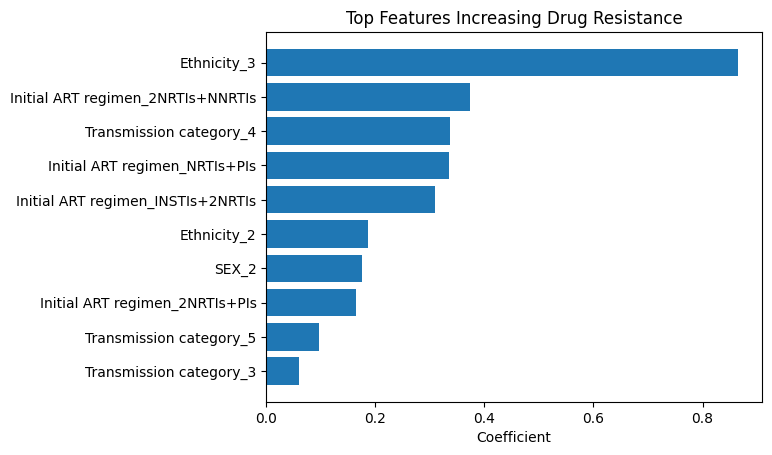

In [37]:
import matplotlib.pyplot as plt

# Top 10 positive
top_positive = coefficients.sort_values(by='Coefficient', ascending=False).head(10)

plt.figure()
plt.barh(top_positive['Feature'], top_positive['Coefficient'])
plt.xlabel('Coefficient')
plt.title('Top Features Increasing Drug Resistance')
plt.gca().invert_yaxis()
plt.show()

## Bar Plot Showing Top Features Decreasing Drug Resistance
This plot highlights variables associated with reduced resistance risk, including higher CD4 counts, longer ART duration, and certain ART regimens.

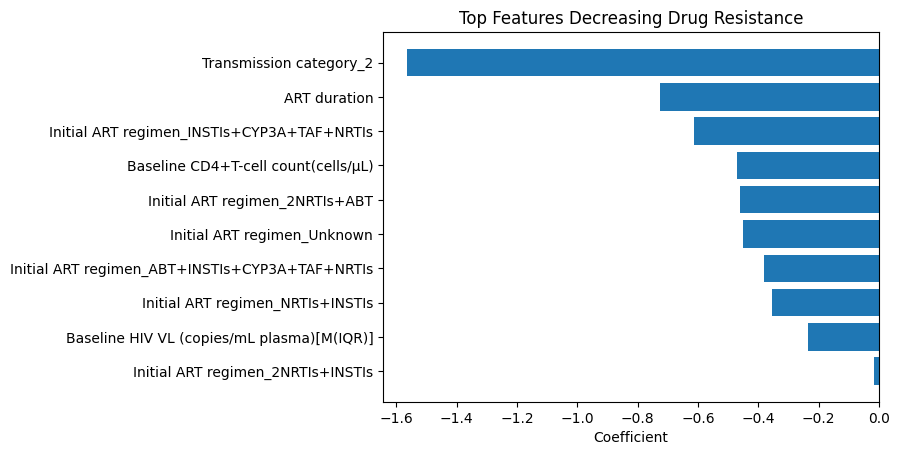

In [38]:
bottom_features = coefficients.sort_values(by='Coefficient').head(10)

plt.figure()
plt.barh(bottom_features['Feature'], bottom_features['Coefficient'])
plt.xlabel('Coefficient')
plt.title('Top Features Decreasing Drug Resistance')
plt.gca().invert_yaxis()
plt.show()

## ROC Curve showing how well the model distinguishes classes.
The ROC curve illustrates the model’s ability to distinguish between resistant and non-resistant patients, with moderate discriminative performance (AUC ≈ 0.63).

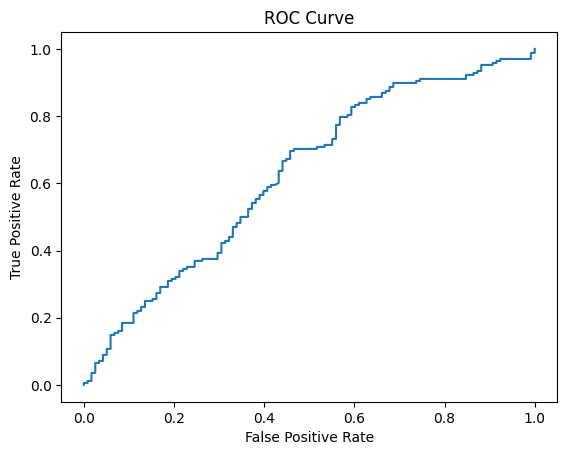

In [39]:
from sklearn.metrics import roc_curve

y_probs = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Confusion Matrix
The confusion matrix shows that the model performs well in identifying resistant patients but struggles to correctly classify non-resistant individuals.

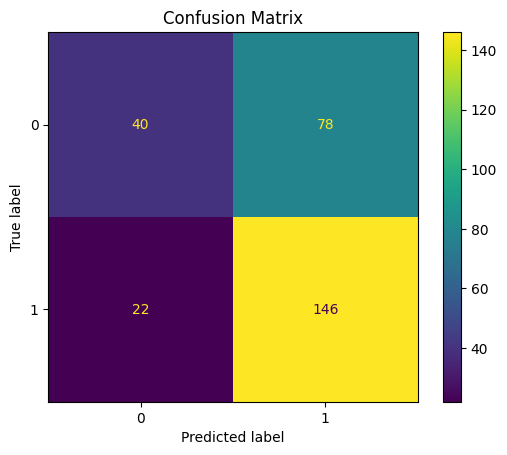

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

## Limitations
- No genotypic (mutation-level) data was included  
- Moderate model performance was exhibited 
- Potential confounding in demographic variables  
- Observational dataset limits causal interpretation  

## Conclusion
This analysis demonstrates that clinical and treatment variables can partially predict HIV drug resistance, but are insufficient alone for high-accuracy prediction.

The findings highlight the importance of incorporating genetic data and suggest that ART regimen and immune status play key roles in resistance risk.

## Extended Analysis: Model Comparison

Following feedback from domain experts, additional models and dimensionality reduction techniques were applied to improve model robustness and evaluate comparative performance.

### Rationale

Logistic regression was used as a baseline model. To improve predictive performance and assess robustness, additional models like Random Forest and  SVM were evaluated. PCA was also applied to address potential multicollinearity introduced during encoding.

### Import Models

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### Initialize Models

In [42]:
lr = LogisticRegression(max_iter=1000)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

svm = SVC(
    probability=True,
    random_state=42
)

### Train + Compare

In [43]:
from sklearn.metrics import roc_auc_score

results = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "ROC-AUC": auc
    })

### Create Comparison Table

In [44]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC
1,Random Forest,0.648835
0,Logistic Regression,0.626539
2,SVM,0.625429


## Interpretation
Random Forest slightly outperforms logistic regression, indicating the presence of non-linear relationships; however, overall model performance remains moderate, suggesting that feature limitations, rather than model choice, are the primary constraint.

## Dimensionality Reduction using PCA

To address potential multicollinearity and redundancy introduced during feature encoding, Principal Component Analysis (PCA) can be applied. PCA reduces the dimensionality of the dataset while retaining most of the variance, allowing models to learn from a more compact and less correlated feature space.

### Import and apply PCA

We import PCA from scikit-learn and apply it to the feature matrix to reduce dimensionality. We retain 95% of the variance, meaning the transformed features capture most of the original information while reducing redundancy.

In [46]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

### Number of Components Retained

We examine how many principal components were retained after applying PCA. This is intended to show how much dimensionality reduction has occurred. We also carrry out an explained variance which shows how much of the original data variability is retained after PCA. Retaining ~95% ensures minimal information loss.

In [47]:
print("Original features:", X.shape[1])
print("Reduced features (PCA):", X_pca.shape[1])

Original features: 22
Reduced features (PCA): 8


In [48]:
print("Total explained variance:", sum(pca.explained_variance_ratio_))

Total explained variance: 0.9614486140857673


### Train-Test Split (PCA Features)

We split the PCA-transformed dataset into training and test sets using the same strategy as before to ensure fair comparison.

In [49]:
from sklearn.model_selection import train_test_split

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

### Model Training on PCA Features

The same models (Logistic Regression, Random Forest, SVM) are trained on the PCA-transformed data to evaluate whether dimensionality reduction improves performance.

In [50]:
results_pca = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    
    y_prob = model.predict_proba(X_test_pca)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    results_pca.append({
        "Model": name,
        "ROC-AUC (PCA)": auc
    })

### Model Performance After PCA

We compare model performance after applying PCA to assess whether reducing feature redundancy improves predictive accuracy.

In [51]:
results_pca_df = pd.DataFrame(results_pca)
results_pca_df.sort_values(by="ROC-AUC (PCA)", ascending=False)

,Model,ROC-AUC (PCA)
0,Logistic Regression,0.625126
1,Random Forest,0.621318
2,SVM,0.606159


## Extended Analysis Interpretation and Findings 

This analysis evaluated whether clinical and treatment variables can be used to predict HIV drug resistance, and explored whether model choice and dimensionality reduction improve predictive performance.

### Model Comparison

Logistic regression was used as a baseline model and compared with Random Forest and Support Vector Machine (SVM). Random Forest demonstrated slightly improved performance (ROC-AUC ~0.65), suggesting the presence of non-linear relationships within the data. However, the improvement over logistic regression was modest, and overall performance across all models remained moderate (~0.62–0.65).

This indicates that while model choice can influence performance, it is not the primary limiting factor in this analysis.

### Effect of Dimensionality Reduction (PCA)

PCA reduced the feature space from 22 variables to 8 principal components while retaining approximately 96% of the variance. Despite this reduction, model performance did not improve and slightly decreased across all models.

This suggests that:
- Feature redundancy and multicollinearity were not significantly impairing model performance  
- The original feature space contained meaningful structure that contributed to prediction  
- Tree-based models such as Random Forest may not benefit from PCA, as they can inherently handle correlated features  

### Key Insight

Across all models and approaches, predictive performance remained moderate. This suggests that the primary limitation is not the modeling approach or feature redundancy, but rather the limited predictive signal in the available variables.

Clinical and treatment variables alone are insufficient to fully capture the complexity of HIV drug resistance.

### Biological Interpretation

HIV drug resistance is fundamentally driven by viral genetic mutations. While clinical variables such as CD4 count, ART regimen, and treatment duration provide some indirect signal, they do not directly capture the underlying biological mechanisms of resistance.

### Conclusion

This analysis demonstrates that:
- More complex models provide only marginal improvement over simpler models  
- Dimensionality reduction does not enhance predictive performance in this context  
- The key limitation lies in the absence of biologically informative features  

Future analyses should incorporate genotypic (mutation-level) data to improve predictive accuracy and better reflect the biological basis of drug resistance.